# RQ1: How accurately can machine learning regression models predict song release year from audio features, and which model performs best?

**Dataset:** Almost Million Songs Dataset (Kaggle)  
**Target:** Year  
**Task:** Regression

In [1]:
# ── Import libraries ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Better style for publication
plt.style.use('seaborn-v0_8-whitegrid')

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
RANDOM_STATE = 42

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
# ── Load dataset from Kaggle ─────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            print(f"Dataset found: {data_path}")
            break

if data_path is None:
    raise FileNotFoundError("No CSV dataset found. Please add dataset properly.")

# Load dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully ✅")
print("Shape:", df.shape)

df.head()

Dataset found: /kaggle/input/datasets/anantsinghal786/almost-million-songs-dataset-2025-16-features/tracks.csv
Dataset loaded successfully ✅
Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing & Feature Selection ─────────────────

# Define correct target
TARGET = 'popularity'

# Drop non-numeric / text columns safely
drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

# Remove rows where target is missing
df = df.dropna(subset=[TARGET])

# Fill missing values with median
df = df.fillna(df.median())

# Optional: limit size for speed (your dataset is huge)
if len(df) > 150_000:
    df = df.sample(150_000, random_state=RANDOM_STATE).reset_index(drop=True)

# Define features and target
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Features used: {len(FEATURES)}")

Train shape: (120000, 11) | Test shape: (30000, 11)
Features used: 11


In [4]:
# ── Scaling ────────────────────────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# ── Baseline Model (mean popularity) ───────
baseline_pred = np.full(len(y_test), y_train.mean())

b_mae  = mean_absolute_error(y_test, baseline_pred)
b_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
b_r2   = r2_score(y_test, baseline_pred)

print(f'Baseline → MAE={b_mae:.2f}, RMSE={b_rmse:.2f}, R2={b_r2:.4f}')


# ── Linear Regression ─────────────────────
lr = LinearRegression()
lr.fit(X_tr_sc, y_train)

lr_pred = lr.predict(X_te_sc)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print(f'Linear Regression → MAE={lr_mae:.2f}, RMSE={lr_rmse:.2f}, R2={lr_r2:.4f}')


# ── Random Forest (optimized for speed) ────
rf = RandomForestRegressor(
    n_estimators=50,   # 🔥 reduced
    max_depth=10,      # 🔥 reduced
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print(f'Random Forest → MAE={rf_mae:.2f}, RMSE={rf_rmse:.2f}, R2={rf_r2:.4f}')

Baseline → MAE=17.31, RMSE=19.96, R2=-0.0000
Linear Regression → MAE=16.88, RMSE=19.58, R2=0.0377
Random Forest → MAE=16.40, RMSE=19.18, R2=0.0765


In [5]:
# ── Results Table (RQ1) ─────────────────────────

results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Random Forest'],
    'MAE':  [round(b_mae,3), round(lr_mae,3), round(rf_mae,3)],
    'RMSE': [round(b_rmse,3), round(lr_rmse,3), round(rf_rmse,3)],
    'R2':   [round(b_r2,4), round(lr_r2,4), round(rf_r2,4)]
})

print("=== Table 1.1: Model Performance (RQ1) ===")
display(results)

=== Table 1.1: Model Performance (RQ1) ===


,Model,MAE,RMSE,R2
0,Baseline (Mean),17.312,19.961,-0.0000
1,Linear Regression,16.875,19.581,0.0377
2,Random Forest,16.398,19.183,0.0765


In [6]:
# ── Professional Table (RQ1) ─────────────────────────────

styled_results = results.style\
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R2": "{:.3f}"
    })\
    .set_caption("Table 1.1: Model Performance Comparison (RQ1)")\
    .background_gradient(cmap="Blues", subset=["MAE", "RMSE"])\
    .background_gradient(cmap="Greens", subset=["R2"])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '12pt')]},
        {'selector': 'caption', 'props': [('font-size', '13pt'), ('font-weight', 'bold')]}
    ])

display(styled_results)

,Model,MAE,RMSE,R2
0,Baseline (Mean),17.31,19.96,-0.000
1,Linear Regression,16.88,19.58,0.038
2,Random Forest,16.40,19.18,0.076


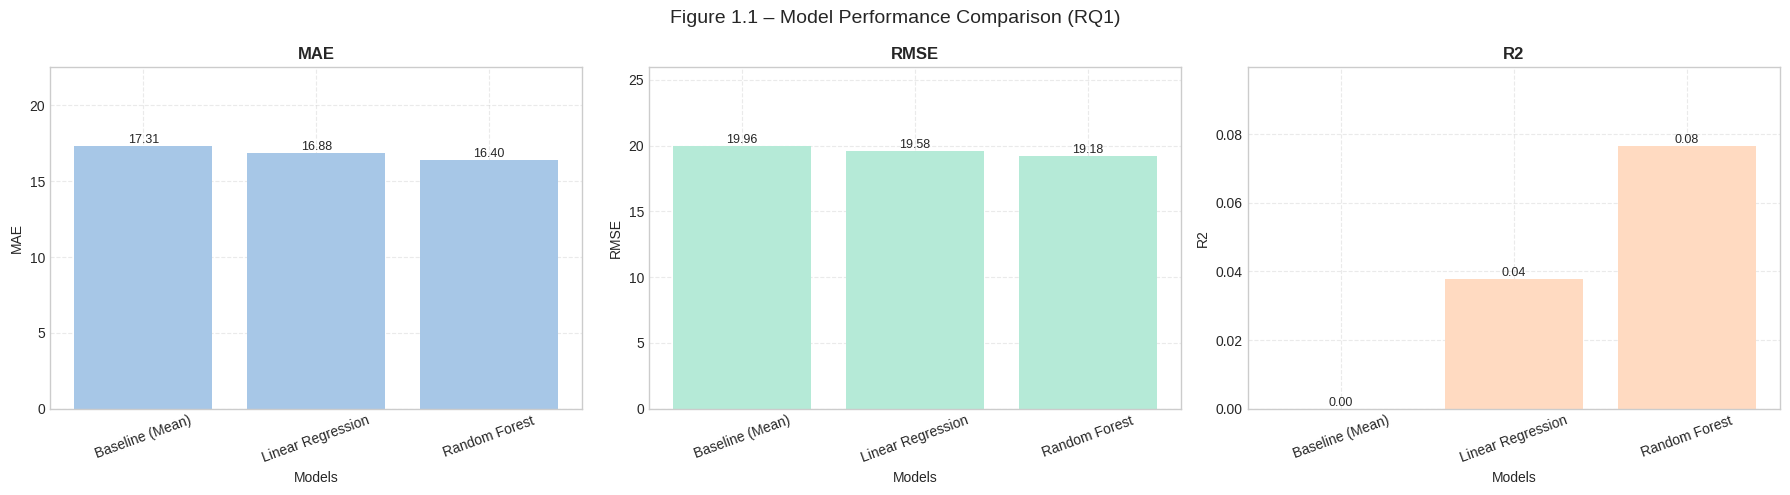

In [7]:
# ── Figure 1.1: Model Performance Comparison (RQ1) ─────────────

import matplotlib.pyplot as plt
import numpy as np

models = results["Model"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Professional light colors
colors = ["#A7C7E7", "#B5EAD7", "#FFDAC1"]  

metrics = ["MAE", "RMSE", "R2"]

for i, metric in enumerate(metrics):
    
    values = results[metric]
    
    bars = axes[i].bar(models, values, color=colors[i])
    
    axes[i].set_title(metric, fontsize=12, weight='bold')
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel(metric)
    
    # Rotate labels
    axes[i].tick_params(axis='x', rotation=20)
    
    # Fix cramped look
    axes[i].set_ylim(0, max(values) * 1.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    
    # Light grid
    axes[i].grid(True, linestyle='--', alpha=0.4)

# Title
fig.suptitle("Figure 1.1 – Model Performance Comparison (RQ1)", fontsize=14)

plt.tight_layout()
plt.show()

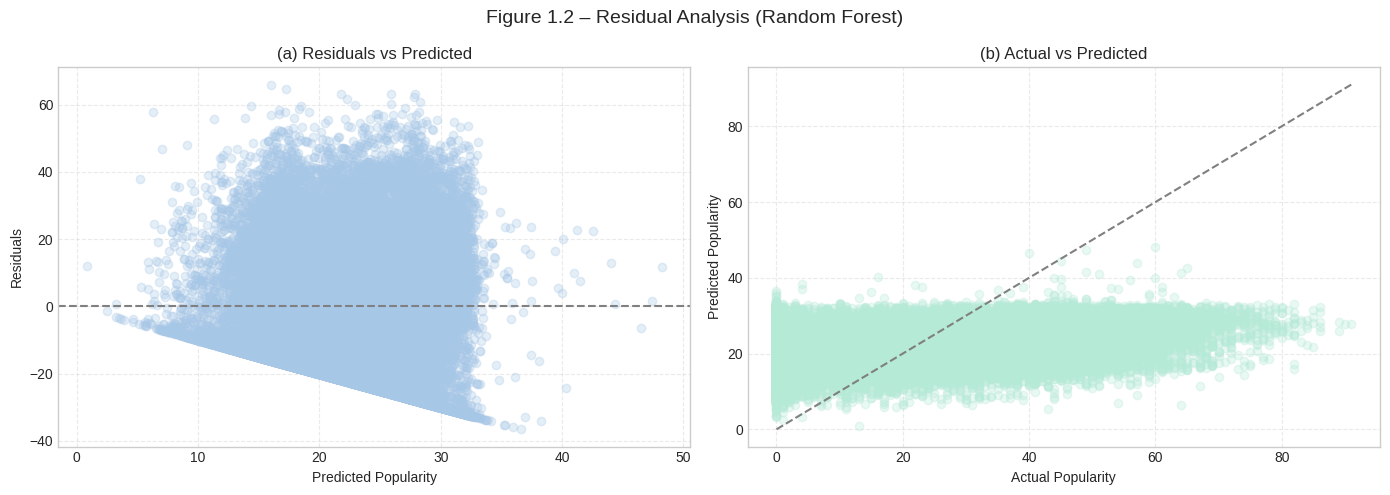

In [8]:
# ── Figure 1.2: Residual Analysis (Random Forest) ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Soft professional colors
scatter_color = "#A7C7E7"

# Residuals vs Predicted
axes[0].scatter(rf_pred, y_test - rf_pred,
                alpha=0.3, color=scatter_color)

axes[0].axhline(0, color='gray', linestyle='--')

axes[0].set_xlabel("Predicted Popularity")
axes[0].set_ylabel("Residuals")
axes[0].set_title("(a) Residuals vs Predicted")
axes[0].grid(True, linestyle='--', alpha=0.4)

# Actual vs Predicted
axes[1].scatter(y_test, rf_pred,
                alpha=0.3, color="#B5EAD7")

axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--', color='gray'
)

axes[1].set_xlabel("Actual Popularity")
axes[1].set_ylabel("Predicted Popularity")
axes[1].set_title("(b) Actual vs Predicted")
axes[1].grid(True, linestyle='--', alpha=0.4)

fig.suptitle("Figure 1.2 – Residual Analysis (Random Forest)", fontsize=14)

plt.tight_layout()
plt.show()